# Concatenate all the lists of the linkers for STA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
import matplotlib
# Set the global fontsize for Matplotlib
matplotlib.rcParams.update({'font.size': 12})  

import warnings
warnings.filterwarnings('ignore')
from cryocat import cryomotl
from cryocat import cryomap
import pandas as pd
import networkx as nx

In [33]:
# load all the lists
###### 
#output_path2='./outputs/outputs_EMD2601/A_linkers_20nm/'
#output_path2='./outputs/outputs_EMD13356/A_linkers_20nm/'
output_path2='./outputs/outputs_EMD13356_STA_tmpl/A_linkers_20nm/'


## Output from trace script from @Beata, with 10nm threshold
## Output from trace script from @Beata, with 10nm threshold
path_mask='./out_tracing/EMD13356_STA_tmpl/'
motl_trace_input=input_motl=path_mask+'EMD13356_tr200nm_STA_tmpl.em'

In [34]:
motl_trace=cryomotl.EmMotl(input_motl=motl_trace_input)
tomograms=motl_trace.df['tomo_id'].unique()

nlinkers=0
motl_lists=[]
for tomo_id in tomograms:
    #if tomo_id!=9:
        #print(f'Tomogram: {tomo_id}')
        df_motl_tomo=motl_trace.df[motl_trace.df['tomo_id']==tomo_id]
        clusters=df_motl_tomo['geom1'].unique()
        for cluster in clusters:
            if cluster>1:
                output_filename=output_path2+f'motl_tomo{tomo_id}_cluster{cluster}_linkers.em'
                try:
                    linkers=cryomotl.EmMotl(input_motl=output_filename)
                    nlinkers=nlinkers+len(linkers.df)
                    motl_lists.append(output_filename)
                except:
                    print(output_filename, 'does not exist!!!' )
                    break
                
                
print(nlinkers)                
#
#cryomotl.merge_and_renumber(motl_list=motl_lists)
print(len(motl_lists))

1
1


In [35]:
merged_motl=cryomotl.Motl.merge_and_renumber(motl_list=motl_lists)
merged_motl.write_out(output_path=output_path2+'Nov_ALL_linkers_with_length_and_bending_angle.em')

In [36]:
merged_motl=cryomotl.EmMotl(input_motl=output_path2+'Nov_ALL_linkers_with_length_and_bending_angle.em')
#merged_motl.df[['x', 'y','z']]=merged_motl.df[['x', 'y','z']]/
#merged_motl.write_out(output_path=output_path2+'BIN2_2TEST_ALL_linkers.em')
#merged_motl_bin2

In [37]:
all_list=cryomotl.EmMotl(input_motl=output_path2+'Nov_ALL_linkers_with_length_and_bending_angle.em')


Text(0, 0.5, 'Frequency')

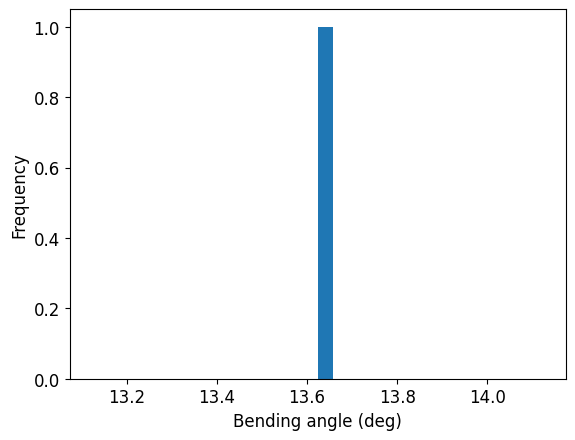

In [38]:
#hist=plt.hist2d(x=(1.971/10.)*all_list.df[['geom4']], y=all_list.df[['geom5']])
hist2=plt.hist(all_list.df[['geom5']], bins=30)
plt.xlabel('Bending angle (deg)')
plt.ylabel('Frequency')

174.68423897879464
geom4    0.0
dtype: float64


Text(0, 0.5, 'Frequency')

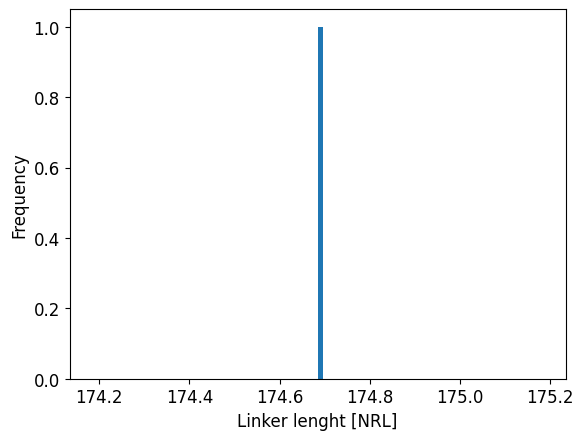

In [39]:
#hist=plt.hist2d(x=(1.971/10.)*all_list.df[['geom4']], y=all_list.df[['geom5']])
hist2=plt.hist((1./10.)*all_list.df[['geom4']]/.35+147, bins=80)

print(np.mean((1./10.)*all_list.df[['geom4']]/.35+147))
print(np.std((1./10.)*all_list.df[['geom4']]/.35+147))
plt.xlabel('Linker lenght [NRL]')
plt.ylabel('Frequency')

In [40]:
all_list.df[['geom4']]

,geom4
0,96.894836


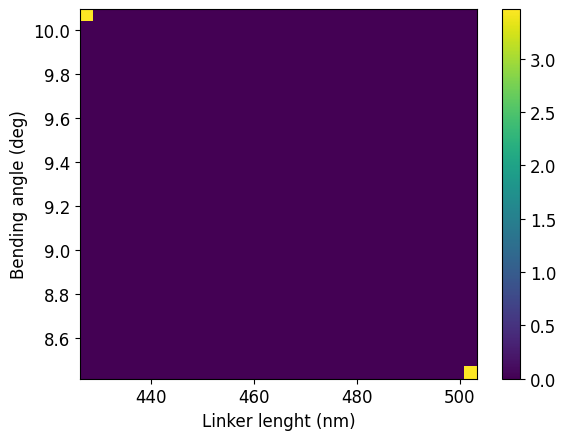

In [68]:
# Big bins
x=(2*1.971/10.)*all_list.df[['geom4']].to_numpy()
y=all_list.df[['geom5']].to_numpy()
plt.hist2d(x[:,0], y[:,0], bins=(30, 30), density=True,  )
plt.xlabel('Linker lenght (nm)')
plt.ylabel('Bending angle (deg)')
plt.colorbar() 
plt.show()


In [ ]:
np.shape(x[:,0])

## Merge Pmax_Psecond - 05112024

In [ ]:
motl_trace=cryomotl.EmMotl(input_motl=motl_trace_input)
tomograms=motl_trace.df['tomo_id'].unique()

nlinkers=0
motl_lists=[]
for tomo_id in tomograms:
    #if tomo_id!=9:
        #print(f'Tomogram: {tomo_id}')
        df_motl_tomo=motl_trace.df[motl_trace.df['tomo_id']==tomo_id]
        clusters=df_motl_tomo['geom1'].unique()
        for cluster in clusters:
            if cluster>1:
                output_filename=f'./outputs/A_Connections_dictionary_20nm/Delta_probs/PmaxPsecond_motl_tomo{tomo_id}_cluster{cluster}_linkers.em'
                try:
                    linkers=cryomotl.EmMotl(input_motl=output_filename)
                    nlinkers=nlinkers+len(linkers.df)
                    motl_lists.append(output_filename)
                except:
                    print(output_filename, 'does not exist!!!' )
                    break
                
                
print(nlinkers)                
#
#cryomotl.merge_and_renumber(motl_list=motl_lists)
print(len(motl_lists))

In [ ]:
merged_motl=cryomotl.Motl.merge_and_renumber(motl_list=motl_lists)
merged_motl.write_out(output_path='./outputs/A_Connections_dictionary_20nm/Delta_probs/PmaxPsecond_ALL_linkers_with_length_and_bending_angle_Rest.em')